# Tarefa 3 - Neural Networks Coursework 2026

Third assessed coursework for **Tecnicas e Algoritmos em Ciencia de Dados**.

Write your 6-digit anonymous identifier in the first code cell. Submit a single notebook named with that identifier, for example `568423.ipynb`. Do not submit datasets or extra Python scripts. Any helper function used by your solution must be included in this notebook.

This notebook is a guide. The TODO cells mark the parts you must implement. The TensorFlow baseline cells are provided so you can compare your own implementations against a standard neural-network baseline.

## Overview

1. Regression with neural networks (50%)
2. Multiclass classification with neural networks (50%)

## General rules

- You may use NumPy and basic libraries for matrix operations.
- You must not use library implementations for the algorithms you are asked to implement manually.
- Standardize features manually using only training-set statistics.
- Use the validation set for model selection.
- Use the test set only for final reporting.
- Restart the kernel and run the full notebook before submitting.


In [1]:
student_id = "810597" # Replace with your 6-digit anonymous identifier.
student_id

'810597'

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, accuracy_score

np.random.seed(0)


In [3]:
# Versions
print(f"SNS: {sns.__version__}")
print(f"PD: {pd.__version__}")
print(f"NP: {np.__version__}")

SNS: 0.13.2
PD: 3.0.1
NP: 2.4.2


# Helper Functions

Implement any shared helper functions here. In particular, you will need a function to standardize validation and test data using the mean and standard deviation computed from the training set.

Do not use `sklearn.preprocessing.StandardScaler` for this coursework requirement.


In [4]:
def standardize_from_train(X_train, X_val, X_test):
    """Standardize X_train, X_val, and X_test using training-set statistics only."""
    # TODO:
    # 1. Compute the mean of each feature using X_train.
    mu = np.mean(X_train, axis=0)

    # 2. Compute the standard deviation of each feature using X_train.
    sigma = np.std(X_train,axis=0)

    # 3. Replace any zero standard deviation with 1.0.
    sigma = np.where(sigma == 0, 1.0, sigma)

    # 4. Transform X_train, X_val, and X_test with the training mean/std.
    X_train_scaled = (X_train - mu) / sigma
    X_val_scaled = (X_val - mu) / sigma
    X_test_scaled = (X_test - mu) / sigma

    # 5. Return the three transformed arrays, plus the mean and std if useful.
    return X_train_scaled, X_val_scaled, X_test_scaled, mu, sigma


def rmse(y_true: np.ndarray, y_pred: np.ndarray):
    """Return the root mean squared error."""
    # TODO: implement RMSE with NumPy.
    if y_true.ndim == 1:
        y_true = y_true.reshape(-1, 1)
    if y_pred.ndim == 1:
        y_pred = y_pred.reshape(-1, 1) 

    return np.sqrt(np.mean((y_pred - y_true)**2))


def multiclass_metrics(y_true_one_hot, predicted_probabilities, predicted_labels):
    """Compute AUROC, precision, F1, and accuracy for multiclass predictions."""
    # TODO: use sklearn metric functions for reporting only.
    # Hint: AUROC should use probabilities. Precision/F1/accuracy use predicted labels.

    y_true_labels = np.argmax(y_true_one_hot, axis=1)

    auroc = roc_auc_score(
        y_true_one_hot, predicted_probabilities, multi_class="ovr"
    )

    precision = precision_score(
        y_true_labels, predicted_labels, average="macro"
    )

    recall = recall_score(
        y_true_labels, predicted_labels, average="macro"
    )

    f1 = f1_score(
        y_true_labels, predicted_labels, average="macro"
    )

    accuracy = accuracy_score(
        y_true_labels, predicted_labels
    )

    return auroc, precision, recall, f1, accuracy


# Part 1 - Regression With Neural Networks (50%)

## Dataset

Use `student_performance.csv`. Each row corresponds to a student. The target is `final_score`.

Required preprocessing:

1. Load the dataset.
2. Data cleaning, droping duplicates, and convert categorical variables to numerical variables.
3. Use `final_score` as the regression target.
4. Do not use `student_id` as a feature.
5. Do not use `passed` as a feature because it is derived from the final score.
6. Split the data into training, validation, and test sets using a 70:15:15 ratio.
7. Standardize features manually using only training-set statistics.


In [5]:
performance = pd.read_csv("student_performance.csv")
display(performance.head(100))
display(performance.describe(include="all"))

,student_id,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,final_score,passed
0,STU0001,Male,15,25,63.8,Bachelor,Yes,Yes,41,67,Yes
1,STU0002,Female,15,2,54.7,Bachelor,Yes,Yes,83,28,No
2,STU0003,Female,19,10,90.5,High School,Yes,No,73,49,No
3,STU0004,Male,16,26,66.8,High School,No,Yes,75,70,Yes
4,STU0005,Female,15,25,73.0,High School,No,Yes,67,77,Yes
...,...,...,...,...,...,...,...,...,...,...,...
95,STU0096,Female,17,12,83.5,Bachelor,No,No,93,55,Yes
96,STU0097,Female,19,3,72.7,Master,No,No,44,44,No
97,STU0098,Female,19,28,99.4,NaN,No,No,36,70,Yes
98,STU0099,Female,19,26,74.9,PhD,Yes,Yes,64,76,Yes


,student_id,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,final_score,passed
count,500,500,500.000000,500.000000,500.000000,383,500,500,500.000000,500.000000,500
unique,500,2,NaN,NaN,NaN,4,2,2,NaN,NaN,2
top,STU0001,Female,NaN,NaN,NaN,Master,Yes,No,NaN,NaN,Yes
freq,1,273,NaN,NaN,NaN,100,254,253,NaN,NaN,323
mean,NaN,NaN,16.978000,15.312000,76.380600,NaN,NaN,NaN,62.986000,55.980000,NaN
std,NaN,NaN,1.434445,8.568167,13.817681,NaN,NaN,NaN,18.937451,15.373754,NaN
min,NaN,NaN,15.000000,2.000000,50.200000,NaN,NaN,NaN,30.000000,20.000000,NaN
25%,NaN,NaN,16.000000,8.000000,64.475000,NaN,NaN,NaN,46.000000,45.000000,NaN
50%,NaN,NaN,17.000000,15.000000,76.500000,NaN,NaN,NaN,64.000000,56.000000,NaN
75%,NaN,NaN,18.000000,23.000000,88.525000,NaN,NaN,NaN,79.000000,68.000000,NaN


In [6]:
# TODO: Regression preprocessing.
# - Convert categorical variables to numerical variables.
pf = performance.drop(columns=["student_id", "passed"]).drop_duplicates()

pf["gender"] = pf["gender"].map({"Male":1, "Female":0})
pf["internet_access"] = pf["internet_access"].map({"Yes":1, "No":0})
pf["extracurricular"] = pf["extracurricular"].map({"Yes":1, "No":0})

pf["parent_education"] = pf["parent_education"].fillna("Other")
pf = pd.get_dummies(
    pf,
    columns=["parent_education"],
    prefix="edu",
    dtype=int
)

# - Set y to the final_score column.
y = pf["final_score"].values

# - Set X to the feature matrix after dropping student_id, final_score, and passed.
X = pf.drop(columns=["final_score"]).values


# Example variable names expected by later cells:
# X = ...
# y = ...



In [7]:
# TODO: Split into train/validation/test using a 70:15:15 ratio.
# Hint: first split off 30% as temporary data, then split that temporary data in half.

X_train, X_aux, y_train, y_aux = train_test_split(X, y, test_size=0.3)
X_val, X_test, y_val, y_test = train_test_split(X_aux, y_aux, test_size=0.5)

X_train, X_val, X_test, mu, sigma = standardize_from_train(X_train, X_val, X_test)

# Expected variable names:
# X_train, X_val, X_test
# y_train, y_val, y_test



## NumPy Regression Neural Network

Implement a fully connected neural network using NumPy.

Requirements:

- The number of hidden layers must be configurable.
- Every hidden layer must have the same number of neurons.
- Use sigmoid activation functions in hidden layers.
- Use a linear output layer.
- Implement forward propagation manually.
- Implement backpropagation manually.
- Support three update methods: batch gradient descent, stochastic gradient descent, and mini-batch gradient descent.
- Use early stopping to prevent overfitting.
- Track training and validation loss at each epoch.
- Use learning rate `0.01`.
- Train for at most `50` epochs.


In [ ]:
# If you want to implement without using POO, you can implement the following functions instead of the NeuralNetworkRegression class.
# My recommended approach is to implement the class, but you can implement the following functions if you prefer a functional programming style.
class NeuralNetworkRegression:
    
    def __init__(
        self,
        input_size: int,
        hidden_layers:int,
        neurons_per_layer:int,
        output_size:int=1,
        random_state:int | None = None
    ):
        # TODO: initialize weights and biases for a variable number of layers.
        """Inicialização dos pesos e bias de toda a rede neural

        Args:
            input_size (int): dimensão dos nossos dados de entrada
            hidden_layers (int): numero de hidden layers
            neurons_per_layer (int): dimensão das hidden layers
            output_size (int, optional): dimensão dos dados de saida. Defaults to 1.
        """

        self.input_size = input_size
        self.hidden_layers = hidden_layers
        self.neurons_per_layer = neurons_per_layer
        self.output_size = output_size
        self.rng = np.random.default_rng(random_state)

        # Mapeira a dimensão de cada camada da rede
        self.layers_structure = (
            [input_size]
            + [neurons_per_layer] * hidden_layers
            + [output_size]
        )

        # Lista com cada matriz W depesos usando o bias trick
        self.weights: list[np.ndarray] = []

        # Subtraimos 1 pois se temos K camadas ao total então precisamos apenas de K - 1 transformações
        for L in range(len(self.layers_structure) - 1): 

            # Como usamos a notação TO-FROM cada uma das nossas
            # W^{(L+1)} tera shape (L+1, L) <-> (dim(out), dim(in)) 
            dim_out = self.layers_structure[L+1]

            # Bias Trick: Aumentamos em 1 a dimensão da camada de entrada para acomodar o vies 
            dim_in = self.layers_structure[L] + 1

            W = self.rng.normal(0.0, 1, size=(dim_out, dim_in))
            self.weights.append(W)


    ############# METODOS AUXILIARES FORWARD E BACKWARD ################

    @staticmethod
    def _ensure_2d(y: np.ndarray) -> np.ndarray:

        # Para converter uma lista em array se necessario
        # Reutiliza se y ja for um nd.array
        y = np.asarray(y)
        if y.ndim == 1:
            # para converter em uma matriz com 1 coluna
            return y.reshape(-1, 1)
        return y
    
    @staticmethod
    def _add_bias(X: np.ndarray) -> np.ndarray:
        ones = np.ones((X.shape[0], 1))
        return np.c_[X, ones]

    @staticmethod
    def sigmoid(a: np.ndarray):
        return 1.0 / (1.0 + np.exp(-np.clip(a, -500, 500)))
    
    ####################################################################

    def forward(self, X:np.ndarray):
        # TODO: implement the forward pass.
        """Realização do foward pass na rede neural com função de ativação sigmoide nas hidden layers

        Args:
            X (np.ndarray): Matriz de dados (sem bias), cada linha representa uma instancia

        Return:
            output (np.ndarray): Predições
            ativations (np.ndarray): Matrizes ativadas de cada camada, iniciando pela input layer finalizando na output layer
        """
        X = np.asarray(X)
        
        activations = [X] # guarda todas as matrizes Z ativadas
        Z = X # A primeira camada por definição ja esta ativada

        # Para cada matriz de pessos W nas hidden layers faremos uma ativação
        for W in self.weights[:-1]:
            # como usamos o Bias Trick devemos adicionar uma coluna de 1s na matriz de dados atual
            Z_bb = self._add_bias(Z) # by bias

            # devemos transpor a matriz W de pesos pois estamos usando a notação TO-FROM
            # na notação TO-FROM cada linha representa um neuronio da camada atual L
            # cada coluna representa um neuronio da camada anterior.
            # Uma matriz W da camada atual é aquela que transforma os dados Z^{L-1} para A^{L-1} 

            A = Z_bb.dot(W.T) # Dados transformados
            Z = self.sigmoid(A)

            activations.append(Z)

        # Para a W da output layer
        W_out = self.weights[-1]

        Z_bb = self._add_bias(Z)
        output = Z_bb.dot(W_out.T)

        activations.append(output)

        return output, activations

    def backward(self, activations: np.ndarray, y_true: np.ndarray):
        """Implementação do backpropagation, ele apenas calcula o gradiente de cada matriz de pesos W

        Args:
            activations (np.ndarray): Matrizes Z ativadas de cada camada da rede neural sem bias na ordem: [X, Z_1, Z_2, ..., Z_out]
            y_true (np.ndarray): Target, saida final esperada
        """
        # TODO: implement backpropagation.

        # Para que y_true não possa quebrar o broadcasting
        y_true = self._ensure_2d(y_true)


        # Lista para armazenar o gradiente de cada matriz W
        gradients = [np.zeros_like(W) for W in self.weights]
        N = y_true.shape[0] # Numero de instancias


        # Calculamos Delta da Output Layer, para saida linear com SSE
        delta = activations[-1] - y_true

        # Então iteramos de tras pra frente, desde a ultima camada ate a primeira
        # [X, Z_1, Z_2, ..., Z_out]

        # se temos 20 camadas então teremos 19 transformações logo os inidices serão = 18, 17, .., 1, 0
        for L in reversed(range(len(self.weights))):
            
            # activations[L] (fisico) é Z^{L} (logico) pois activations começa com os dados de entrada X
            # self.weight[L] (fisico) é W^{L+1} (logico) pois weights inicia com W^{1} #weights = num_camadas - 1
            # Logo Z_in é a matriz de dados (sem bias) que usamos para gerar a camada L+1

            Z_in =  activations[L]

            # Precisamos então adicioanar o bias em Z_in
            Z_in_bb = self._add_bias(Z_in)

            # Calculamos o gradiente do W atual
            gradients[L] = (delta.T).dot(Z_in_bb) / N

            # Calculamos o delta da camada anterior D^{L-1} = D^{L}W^{L} * Z^{L-1} * (1 - Z^{L-1})
            # Neste caso o Z^{L-1} teorico aqui é dado por activations[L].
            if L > 0:
                W_nb = self.weights[L][:,:-1] # W no bias #MONITORIA DUVIDA por que tiramos o bias ?
                Z_prev = activations[L]
                delta = delta.dot(W_nb) * (Z_prev * (1 - Z_prev))

        return gradients
    
    ################# METODOS AUXILIARES FIT ##################################
    def _update_weights(self, gradients: list[np.ndarray], learning_rate: float) -> None:
        for i in range(len(self.weights)):
            self.weights[i] -= learning_rate * gradients[i]

    def _create_batches(
        self,
        X: np.ndarray,
        Y: np.ndarray,
        update_method: str,
        batch_size: int,
    ) -> list[tuple[np.ndarray, np.ndarray]]:
        N = X.shape[0]

        if update_method == "batch":
            return [(X, Y)]
        
        if update_method == "sgd":
            return [(X[i:i+1], Y[i:i+1]) for i in range(N)]
        
        # De forma predeterminada usaremos minibatch
        batches = []
        for inicio in range(0, N, batch_size):
            fim = inicio + batch_size
            batches.append((X[inicio:fim], Y[inicio:fim]))

        return batches
    
    ##########################################################################

    def fit(
        self,
        X_train: np.ndarray,
        y_train: np.ndarray,
        X_val: np.ndarray | None = None,
        y_val: np.ndarray | None = None,
        epochs: int = 50,
        learning_rate: float = 0.01,
        update_method: str = "mini_batch",
        batch_size: int = 32,
        patience: int = 10,
    ) -> tuple[list[float], list[float], int, int]:
        """Treina o modelo atual com o conjunto de dados
        Args:
            X_train (np.ndarray): Conjunto de dados
            y_train (np.ndarray): Targets do conjunto de dados
            X_val (np.ndarray | None, optional): Conjunto de validação para obter val_loss_history e/ou para realizar early stoped. Defaults to None.
            y_val (np.ndarray | None, optional): Targets do conjunto de validação. Defaults to None.
            epochs (int, optional): Numero de epocas a ser efetuadas. Defaults to 50.
            learning_rate (float, optional): taxa de aprendizado. Defaults to 0.01.
            update_method (str, optional): metodo de atualização _("batch", "sgt", "mini_batch")_. Defaults to "mini_batch".
            batch_size (int, optional): Tamanho dos mini_batches. Defaults to 32.
            patience (int, optional): Patience para o early stop. Defaults to 10.

        Returns:
            train_loss (list[float]): Train Loss History for each epoch
            validation_loss (list[float] | None): Validation Loss History for each epoch
            stoped_epoch (int | None): Epoch de parada
            best_epoch (int | None): Epoch onde se encontra o melhor erro
        """
        # TODO: implement training with batch, SGD, and mini-batch updates.
        # TODO: implement early stopping and restore the best weights.
        # TODO: return training and validation loss histories.

        X_train = np.asarray(X_train)
        y_train = self._ensure_2d(np.asarray(y_train))

        use_validation = X_val is not None and y_val is not None
        if use_validation:
            X_val = np.asarray(X_val)
            y_val = self._ensure_2d(np.asarray(y_val))

        training_loss: list[float] = []
        validation_loss: list[float] = []

        best_val_err = float("inf")
        best_epoch = -1
        stopped_epoch = epochs
        patience_count = 0
        best_weights = [W.copy() for W in self.weights]

        for epoch in range(1, epochs + 1):

            if update_method in ("sgd", "mini_batch"):
                indices = np.random.permutation(X_train.shape[0])
                X_epoch = X_train[indices]
                y_epoch = y_train[indices]
            else:
                X_epoch = X_train
                y_epoch = y_train


            batches = self._create_batches(X_epoch, y_epoch, update_method, batch_size)
            for X_batch, y_batch in batches:
                # Fazer o Forward pass no batch para calcular as ativacoes
                _, activations = self.forward(X_batch)

                # Fazer o Backward para calcular os gradientes
                gradients = self.backward(activations, y_batch)

                # Substituir os pesos W
                self._update_weights(gradients, learning_rate)

            # Loss history do treino
            y_train_pred, _ = self.forward(X_train)
            train_err = rmse(y_train, y_train_pred)
            training_loss.append(train_err)

            # Loss de validation (opcional)
            if use_validation:
                y_val_pred, _ = self.forward(X_val)
                val_err = rmse(y_val, y_val_pred)
                validation_loss.append(val_err)

                if val_err < best_val_err:
                    best_val_err = val_err
                    best_epoch = epoch
                    best_weights = [W.copy() for W in self.weights]
                    patience_count = 0
                else:
                    patience_count += 1
                
                stopped_epoch = epoch
                
                if patience_count is not None and patience_count >= patience:
                    break

        if use_validation and best_epoch != -1:
            self.weights = best_weights
        
        return training_loss, validation_loss, stopped_epoch, best_epoch

    def predict(self, X: np.ndarray) -> np.ndarray:
        # TODO: return predictions from the network.
        pred, _ = self.forward(X)
        return pred

## Regression Hyperparameter Tuning

Choose:

- 3 values for number of hidden layers, for example `[1, 2, 3]`.
- 3 values for neurons per hidden layer, for example `[100, 150, 250]`.
- The 3 update methods: batch GD, SGD, and mini-batch GD.

For each combination, train the model and record the validation RMSE. This gives 27 validation results.


In [9]:
regression_hidden_layers = [1, 2, 3]
regression_neurons = [16, 32, 64]
regression_update_methods = ["batch", "sgd", "mini_batch"]
regression_learning_rate = 0.01
regression_epochs = 50
regression_patience = 10

results = []
best_err = float("inf")
best_train_loss = None
best_val_loss = None
best_stopped_epoch = 0
best_best_epoch = 0

# TODO: train every architecture/update-method combination.
# Store at least: update_method, hidden_layers, neurons_per_layer, validation_rmse, best_epoch, stopped_epoch.
for cada_update_method in regression_update_methods:
    for cada_num_hidden in regression_hidden_layers:
        for cada_num_neuronios in regression_neurons:
            NN = NeuralNetworkRegression(
                input_size=X_train.shape[1],
                hidden_layers=cada_num_hidden,
                neurons_per_layer=cada_num_neuronios,
                output_size=1,
                random_state=0
            )

            training_loss, validation_loss, stopped_epoch, best_epoch = NN.fit(
                X_train,
                y_train,
                X_val,
                y_val,
                epochs=regression_epochs,
                learning_rate=regression_learning_rate,
                update_method=cada_update_method,
                patience=regression_patience
            )

            y_val_pred, _ = NN.forward(X_val)
            err_val = rmse(y_val, y_val_pred)

            if err_val < best_err:
                best_err = err_val
                best_train_loss = training_loss
                best_val_loss = validation_loss
                best_stopped_epoch = stopped_epoch
                best_best_epoch = best_epoch


            results.append({
                "update_method":cada_update_method,
                "hidden_layers":cada_num_hidden,
                "neurons_per_layer":cada_num_neuronios,
                "validation_rmse": err_val,
                "best_epoch": best_epoch,
                "stopped_epoch": stopped_epoch
            })


# regression_results = pd.DataFrame(...)
# display(regression_results.sort_values("validation_rmse"))

regression_results = pd.DataFrame(results)
display(regression_results.sort_values("validation_rmse"))



,update_method,hidden_layers,neurons_per_layer,validation_rmse,best_epoch,stopped_epoch
23,mini_batch,2,64,7.114888,13,23
20,mini_batch,1,64,7.168868,47,49
11,sgd,1,64,7.208157,3,13
22,mini_batch,2,32,7.315271,22,32
16,sgd,3,32,7.382625,3,13
21,mini_batch,2,16,7.392965,33,43
25,mini_batch,3,32,7.430991,28,38
19,mini_batch,1,32,7.480751,48,49
10,sgd,1,32,7.544204,5,15
26,mini_batch,3,64,7.618566,23,33


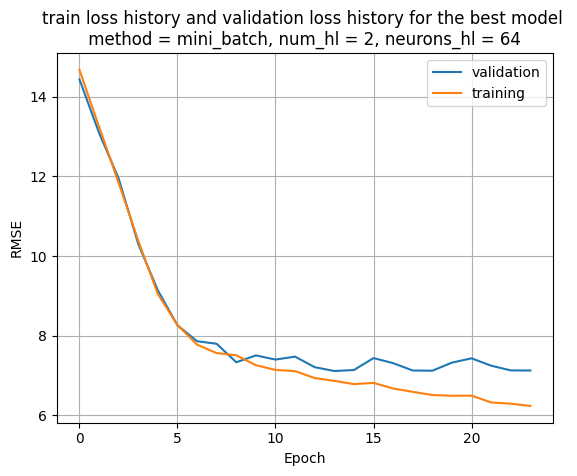

In [10]:
# TODO: Plot training and validation loss curves for the selected/best model.
bm = regression_results.sort_values("validation_rmse").values[0] # Best Model

plt.plot(range(best_stopped_epoch+1), best_val_loss, label="validation")
plt.plot(range(best_stopped_epoch+1), best_train_loss, label="training")

plt.grid()
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title(f"train loss history and validation loss history for the best model \n method = {bm[0]}, num_hl = {bm[1]}, neurons_hl = {bm[2]} ")
plt.legend()
plt.show()

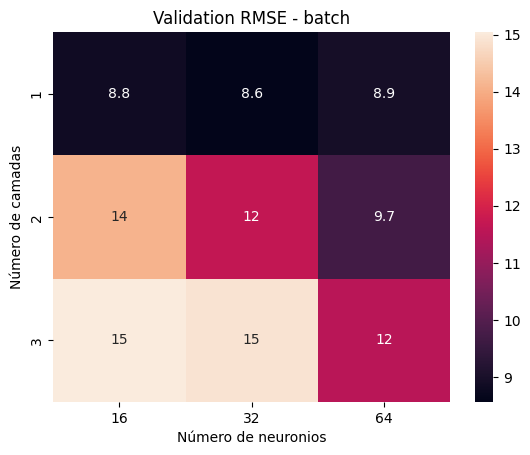

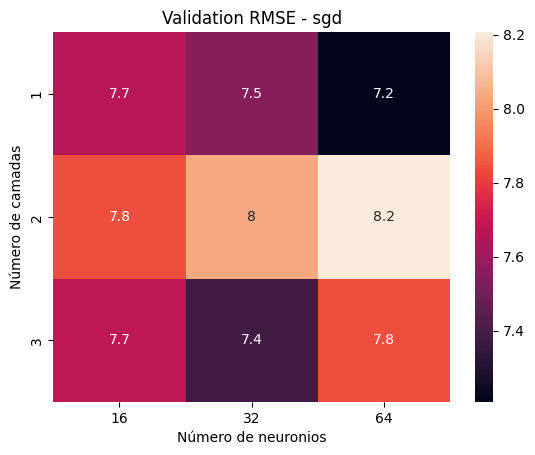

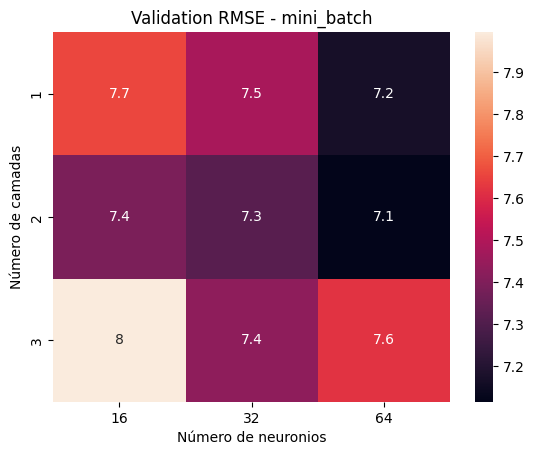

In [11]:
# TODO: Produce one validation RMSE heatmap per update method.
# Rows: number of hidden layers.
# Columns: neurons per hidden layer.
# Values: validation RMSE.

rr = regression_results

for x in regression_update_methods:
    heatmap_data = rr[rr["update_method"] == x].pivot(
    index="hidden_layers",
    columns="neurons_per_layer",
    values="validation_rmse"
    )

    sns.heatmap(
        heatmap_data,
        annot=True,
    )

    plt.title(f"Validation RMSE - {x}")
    plt.xlabel("Número de neuronios")
    plt.ylabel("Número de camadas")
    plt.show()


In [12]:
# TODO: Select the final NumPy regression model using validation RMSE only.
# Then evaluate that selected model on the test set with RMSE.

# Expected variable names for the TensorFlow baseline cell:
# best_hidden_layers = ...
# best_neurons = ...
# best_regression_test_rmse = ...
# best_regression_validation_rmse = ...

whole_X_train = np.r_[X_train, X_val]
whole_y_train = np.r_[y_train, y_val]

# bm is the best model 

best_update_method = bm[0]
best_hidden_layers = bm[1]
best_neurons = bm[2]
best_regression_validation_rmse = bm[3]
best_epoch = bm[4]

bestNNR = NeuralNetworkRegression(
    input_size=X_train.shape[1],
    hidden_layers=best_hidden_layers,
    neurons_per_layer=best_neurons,
    output_size=1
)

bestNNR.fit(
    whole_X_train,
    whole_y_train,
    epochs=best_epoch,
    learning_rate=0.01,
    update_method=best_update_method
)

y_test_pred = bestNNR.predict(X_test)

best_regression_test_rmse = rmse(y_test, y_test_pred)
display(best_regression_test_rmse)


np.float64(8.217141434036229)

## Scratch Linear Regression Baseline

Use your own linear regression implementation from previous labs or courseworks. Train it on the same training set and evaluate it on the same test set.


In [13]:
whole_X_train = np.r_[X_train, X_val]
whole_y_train = np.r_[y_train, y_val]

class ScratchLinearRegression:
    def __init__(self, input_size,):
        self.weight = np.random.normal(0.0, 0.1, size=(input_size + 1))

    @staticmethod
    def _add_bias(X: np.ndarray) -> np.ndarray:
        ones = np.ones((X.shape[0], 1))
        return np.c_[X, ones]
        
    def fit(self, X, y, epochs=50, learning_rate=0.01):
        # TODO: paste/adapt your previous linear regression implementation.

        N = y.shape[0]
        rmse_history = np.zeros(epochs)
        X_bb = self._add_bias(X)

        for cada_epoca in range(epochs):
            # NOTE: Relebrar isso aqui 
            gradiente = ((X_bb.dot(self.weight) - y).T.dot(X_bb)) / N
            self.weight -= learning_rate * gradiente

        # Grabando o erro
            err = rmse(y, X_bb.dot(self.weight))
            rmse_history[cada_epoca] = err

        return rmse_history

    def predict(self, X):
        # TODO: return predictions.
        X_bb = self._add_bias(X)
        pred = X_bb.dot(self.weight)
        return pred

# TODO: train and evaluate your scratch linear regression baseline.

LineaR = ScratchLinearRegression(whole_X_train.shape[1])
loss_err_history_scrach = LineaR.fit(whole_X_train, whole_y_train, 50, 0.01)
y_test_pred_linear = LineaR.predict(X_test)

linear_regression_test_rmse = rmse(y_true=y_test, y_pred=y_test_pred_linear)
linear_regression_test_rmse

np.float64(38.03269103853694)

## TensorFlow Regression Baseline

This baseline is provided. Run it after you have created `X_train`, `X_val`, `X_test`, `y_train`, `y_val`, `y_test`, `best_hidden_layers`, and `best_neurons`.


In [14]:
import tensorflow as tf

tf.random.set_seed(0)

if "best_hidden_layers" not in globals() or "best_neurons" not in globals():
    raise NameError("Define best_hidden_layers and best_neurons from your validation search before running this cell.")

regression_patience = globals().get("regression_patience", 10)
regression_epochs = globals().get("regression_epochs", 50)
regression_learning_rate = globals().get("regression_learning_rate", 0.01)

tf_regression_model = tf.keras.Sequential()
tf_regression_model.add(tf.keras.layers.Input(shape=(X_train.shape[1],)))
for _ in range(int(best_hidden_layers)):
    tf_regression_model.add(tf.keras.layers.Dense(int(best_neurons), activation="sigmoid"))
tf_regression_model.add(tf.keras.layers.Dense(1, activation="linear"))

tf_regression_model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=regression_learning_rate),
    loss="mse",
)

tf_regression_history = tf_regression_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=regression_epochs,
    batch_size=32,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=regression_patience,
            restore_best_weights=True,
        )
    ],
    verbose=0,
)

tf_regression_val_predictions = tf_regression_model.predict(X_val, verbose=0)
tf_regression_test_predictions = tf_regression_model.predict(X_test, verbose=0)

tf_regression_results = pd.DataFrame([
    {
        "model": "TensorFlow regression baseline",
        "hidden_layers": int(best_hidden_layers),
        "neurons_per_layer": int(best_neurons),
        "validation_rmse": float(np.sqrt(np.mean((y_val - tf_regression_val_predictions) ** 2))),
        "test_rmse": float(np.sqrt(np.mean((y_test - tf_regression_test_predictions) ** 2))),
        "epochs_trained": len(tf_regression_history.history["loss"]),
    }
])

display(tf_regression_results)

I0000 00:00:1779643392.401361    4790 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779643393.879537    4790 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779643399.757928    4790 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
E0000 00:00:1779643401.862564    4790 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


,model,hidden_layers,neurons_per_layer,validation_rmse,test_rmse,epochs_trained
0,TensorFlow regression baseline,2,64,19.779031,21.726755,19


In [15]:
# TODO: Build the final regression comparison table.
# Include at least:
# - your NumPy NN
# - your scratch linear regression
# - the TensorFlow baseline above

rmse_nn = best_regression_test_rmse
rmse_linear = linear_regression_test_rmse
rmse_tf = tf_regression_results.values[0][4]


resultados = {
    "Modelo": [
        "Rede Neural (NumPy)",
        "Regressão Linear (Scratch)",
        "Baseline (Tensorflow)"
    ],
    "RMSE teste":[rmse_nn, rmse_linear, rmse_tf]
}

tabela_comparacao = pd.DataFrame(resultados)
display(tabela_comparacao)

,Modelo,RMSE teste
0,Rede Neural (NumPy),8.217141
1,Regressão Linear (Scratch),38.032691
2,Baseline (Tensorflow),21.726755


# Part 2 - Multiclass Classification With Neural Networks (50%)

## Dataset

Use `dry_bean_database.csv`. Each row is one bean described by 16 numerical features. The target column is `Class`, with 7 mutually exclusive classes.

Required preprocessing:

1. Load the dataset.
2. Remove duplicated rows.
3. Convert numeric feature columns when needed. Some copies may store decimal values as strings with comma separators.
4. Encode `Class` as a multiclass target.
5. Split into training, validation, and test sets using a 70:15:15 ratio. Use stratification.
6. Standardize features manually using only training-set statistics.


In [16]:
dry_beans = pd.read_csv("dry_bean_database.csv", decimal=",")
display(dry_beans.head())
display(dry_beans.describe(include="all"))
display(dry_beans.info())

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DERMASON
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3546
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063,NaN
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366,NaN
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687,NaN
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703,NaN
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386,NaN
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883,NaN


<class 'pandas.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  str    
dtypes: float64(14), int64(2

None

In [ ]:
dry_beans = pd.read_csv("dry_bean_database.csv", decimal=",")
# TODO: Classification preprocessing.
# - Drop duplicate rows.
dry_beans = dry_beans.drop_duplicates()

# - Convert all feature columns to float.
# Não precisa

# - Encode Class as integers and one-hot vectors.
dry_beans_one_hot = pd.get_dummies(
    dry_beans,
    columns=["Class"],
    prefix="",
    dtype=int
)

class_names = dry_beans.iloc[:,16:].values
X = dry_beans.iloc[:,:16].values

class_labels = np.argmax(dry_beans_one_hot.iloc[:,16:], axis=1)
y = dry_beans_one_hot.iloc[:,16:].values


# Expected variable names:
# class_names = [...]
# X = ...
# class_labels = ...
# y = ...  # one-hot encoded target



In [18]:
# TODO: Split into train/validation/test using a 70:15:15 ratio with stratification.
# TODO: Standardize X_train, X_val, and X_test using only training-set statistics.

X_train, X_aux, y_train, y_aux = train_test_split(X, y, test_size=0.3)
X_val, X_test, y_val, y_test = train_test_split(X_aux, y_aux, test_size=0.5)

X_train, X_val, X_test, mu, std = standardize_from_train(X_train, X_val, X_test)

labels_train = np.argmax(y_train, axis=1)
labels_val = np.argmax(y_val, axis=1)
labels_test = np.argmax(y_test, axis=1)

# Expected variable names:
# X_train, X_val, X_test
# y_train, y_val, y_test
# labels_train, labels_val, labels_test


## NumPy Multiclass Neural Network

Implement a fully connected multiclass classifier using NumPy.

Requirements:

- The architecture must accept a list of hidden-layer sizes, for example `[64, 128, 256]`.
- Use sigmoid activation functions in hidden layers.
- Use softmax in the output layer.
- Use multiclass cross-entropy loss.
- Implement forward propagation manually.
- Implement backpropagation manually.
- Support batch GD, SGD, and mini-batch GD.
- Use early stopping.
- Track training and validation loss at each epoch.
- Use learning rate `0.01`.
- Train for at most `1000` epochs.


In [ ]:
class NeuralNetworkMulticlassClassifier:
    def __init__(self, input_size, hidden_layers, output_size, random_state = None):
        # TODO: initialize weights and biases for the architecture list.
        self.input_size = input_size
        self.hidden_layers = hidden_layers
        self.output_size = output_size
        self.rng = np.random.default_rng(random_state)

        # Mapeira a dimensão de cada camada da rede
        self.layers_structure = (
            [input_size]
            + hidden_layers
            + [output_size]
        )

        # Lista com cada matriz W depesos usando o bias trick
        self.weights: list[np.ndarray] = []

        # Subtraimos 1 pois se temos K camadas ao total então precisamos apenas de K - 1 transformações
        for L in range(len(self.layers_structure) - 1): 

            # Como usamos a notação TO-FROM cada uma das nossas
            # W^{(L+1)} tera shape (L+1, L) <-> (dim(out), dim(in)) 
            dim_out = self.layers_structure[L+1]

            # Bias Trick: Aumentamos em 1 a dimensão da camada de entrada para acomodar o vies 
            dim_in = self.layers_structure[L] + 1

            W = self.rng.normal(0, 1, size=(dim_out, dim_in))
            self.weights.append(W)

    ############# METODOS AUXILIARES FORWARD E BACKWARD ################

    @staticmethod
    def _ensure_2d(y: np.ndarray) -> np.ndarray:

        # Para converter uma lista em array se necessario
        # Reutiliza se y ja for um nd.array
        y = np.asarray(y)
        if y.ndim == 1:
            # para converter em uma matriz com 1 coluna
            return y.reshape(-1, 1)
        return y
    
    @staticmethod
    def _ensure_onehot(y: np.ndarray, num_classes: int = None) -> np.ndarray:
        """deve ser usado _ensure_2d primeiro"""

        if y.shape[1] > 1:
            return y
        
        num_amostras = y.shape[0]

        if num_classes is None:
            num_cat = int(np.max(y)) + 1
        else:
            num_cat = num_classes


        y_true = np.zeros((num_amostras, num_cat))
        y_flat = y.flatten().astype(int)
        y_true[np.arange(num_amostras), y_flat] = 1

        return y_true

    
    @staticmethod
    def _add_bias(X: np.ndarray) -> np.ndarray:
        ones = np.ones((X.shape[0], 1))
        return np.c_[X, ones]

    @staticmethod
    def sigmoid(a: np.ndarray):
        return 1.0 / (1.0 + np.exp(-np.clip(a, -500, 500)))
    
    @staticmethod
    def softmax(a: np.ndarray):
        a_shift = a - np.max(a, axis=1, keepdims=True)

        exps = np.exp(a_shift)

        return  exps / np.sum(exps, axis=1, keepdims=True)
    
    ####################################################################
    
    def forward(self, X:np.ndarray):
    # TODO: implement sigmoid hidden layers and softmax output.
        """Realização do foward pass na rede neural com função de ativação sigmoide nas hidden layers e funçao softmax na output layer

        Args:
            X (np.ndarray): Matriz de dados (sem bias), cada linha representa uma instancia

        Return:
            output (np.ndarray): Predições
            ativations (np.ndarray): Matrizes ativadas de cada camada, iniciando pela input layer finalizando na output layer
        """
        X = np.asarray(X)
        
        activations = [X] # guarda todas as matrizes Z ativadas
        Z = X # A primeira camada por definição ja esta ativada

        # Para cada matriz de pessos W nas hidden layers faremos uma ativação
        for W in self.weights[:-1]:
            # como usamos o Bias Trick devemos adicionar uma coluna de 1s na matriz de dados atual
            Z_bb = self._add_bias(Z) # by bias

            # devemos transpor a matriz W de pesos pois estamos usando a notação TO-FROM
            # na notação TO-FROM cada linha representa um neuronio da camada atual L
            # cada coluna representa um neuronio da camada anterior.
            # Uma matriz W da camada atual é aquela que transforma os dados Z^{L-1} para A^{L-1} 

            A = Z_bb.dot(W.T) # Dados transformados
            Z = self.sigmoid(A)

            activations.append(Z)

        # Para a W da output layer
        W_out = self.weights[-1]

        Z_bb = self._add_bias(Z)
        A_out = Z_bb.dot(W_out.T)
        Z_out = self.softmax(A_out)

        activations.append(Z_out)

        return Z_out, activations

    def backward(self, activations: np.ndarray, y_true: np.ndarray):
        # TODO: implement backpropagation for softmax + cross-entropy.
        """Implementação do backpropagation, ele apenas calcula o gradiente de cada matriz de pesos W

        Args:
            activations (np.ndarray): Matrizes Z ativadas de cada camada da rede neural sem bias na ordem: [X, Z_1, Z_2, ..., Z_out]
            y_true (np.ndarray): Target, saida final esperada em one-hot encoding
        """

        # Para que y_true não possa quebrar o broadcasting
        y_true = self._ensure_2d(y_true)

        # Lista para armazenar o gradiente de cada matriz W
        gradients = [np.zeros_like(W) for W in self.weights]
        N = y_true.shape[0] # Numero de instancias

        # Calculamos Delta da Output Layer
        delta = activations[-1] - y_true

        # Então iteramos de tras pra frente, desde a ultima camada ate a primeira
        # [X, Z_1, Z_2, ..., Z_out]

        # se temos 20 camadas então teremos 19 transformações logo os inidices serão = 18, 17, .., 1, 0
        for L in reversed(range(len(self.weights))):
            
            # activations[L] (fisico) é Z^{L} (logico) pois activations começa com os dados de entrada X
            # self.weight[L] (fisico) é W^{L+1} (logico) pois weights inicia com W^{1} #weights = num_camadas - 1
            # Logo Z_in é a matriz de dados (sem bias) que usamos para gerar a camada L+1

            Z_in =  activations[L]

            # Precisamos então adicioanar o bias em Z_in
            Z_in_bb = self._add_bias(Z_in)

            # Calculamos o gradiente do W atual
            gradients[L] = (delta.T).dot(Z_in_bb) / N

            # Calculamos o delta da camada anterior D^{L-1} = D^{L}W^{L} * Z^{L-1} * (1 - Z^{L-1})
            # Neste caso o Z^{L-1} teorico aqui é dado por activations[L].
            if L > 0:
                W_nb = self.weights[L][:,:-1] # W no bias #MONITORIA DUVIDA por que tiramos o bias ?
                Z_prev = activations[L]
                delta = delta.dot(W_nb) * (Z_prev * (1 - Z_prev))

        return gradients
    
    ################# METODOS AUXILIARES FIT ##################################
    def _update_weights(self, gradients: list[np.ndarray], learning_rate: float) -> None:
        for i in range(len(self.weights)):
            self.weights[i] -= learning_rate * gradients[i]

    def _create_batches(
        self,
        X: np.ndarray,
        Y: np.ndarray,
        update_method: str,
        batch_size: int,
    ) -> list[tuple[np.ndarray, np.ndarray]]:
        N = X.shape[0]

        if update_method == "batch":
            return [(X, Y)]
        
        if update_method == "sgd":
            return [(X[i:i+1], Y[i:i+1]) for i in range(N)]
        
        # De forma predeterminada usaremos minibatch
        batches = []
        for inicio in range(0, N, batch_size):
            fim = inicio + batch_size
            batches.append((X[inicio:fim], Y[inicio:fim]))

        return batches
    
    @staticmethod
    def categorical_crossentropy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
        y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
        return -np.sum(y_true * np.log(y_pred)) / y_true.shape[0]
    
    ##########################################################################

    def fit(
        self,
        X_train,
        y_train,
        X_val = None,
        y_val = None,
        epochs=1000,
        learning_rate=0.01,
        update_method="mini_batch",
        batch_size=256,
        patience=50,
    ):
        # TODO: implement training with batch, SGD, and mini-batch updates.
        # TODO: implement early stopping and restore the best weights.
        """Treina o modelo atual com o conjunto de dados
        Args:
            X_train (np.ndarray): Conjunto de dados
            y_train (np.ndarray): Targets do conjunto de dados
            X_val (np.ndarray | None, optional): Conjunto de validação para obter val_loss_history e/ou para realizar early stoped. Defaults to None.
            y_val (np.ndarray | None, optional): Targets do conjunto de validação. Defaults to None.
            epochs (int, optional): Numero de epocas a ser efetuadas. Defaults to 1000.
            learning_rate (float, optional): taxa de aprendizado. Defaults to 0.01.
            update_method (str, optional): metodo de atualização _("batch", "sgt", "mini_batch")_. Defaults to "mini_batch".
            batch_size (int, optional): Tamanho dos mini_batches. Defaults to 256.
            patience (int, optional): Patience para o early stop. Defaults to 50.

        Returns:
            train_loss (list[float]): Train Loss History for each epoch
            validation_loss (list[float] | None): Validation Loss History for each epoch
            stoped_epoch (int | None): Epoch de parada
            best_epoch (int | None): Epoch onde se encontra o melhor erro
        """
        # TODO: implement training with batch, SGD, and mini-batch updates.
        # TODO: implement early stopping and restore the best weights.
        # TODO: return training and validation loss histories.

        X_train = np.asarray(X_train)
        y_train = self._ensure_2d(y_train)
        y_train = self._ensure_onehot(y_train)

        use_validation = X_val is not None and y_val is not None
        if use_validation:
            X_val = np.asarray(X_val)
            y_val = self._ensure_2d(y_val)
            y_val = self._ensure_onehot(y_val)

        training_loss: list[float] = []
        validation_loss: list[float] = []

        best_val_err = float("inf")
        best_epoch = -1
        stopped_epoch = epochs - 1
        patience_count = 0
        best_weights = [W.copy() for W in self.weights]

        for epoch in range(1, epochs + 1):
            if update_method in ("sgd", "mini_batch"):
                indices = np.random.permutation(X_train.shape[0])
                X_epoch = X_train[indices]
                y_epoch = y_train[indices]
            else:
                X_epoch = X_train
                y_epoch = y_train

            batches = self._create_batches(X_epoch, y_epoch, update_method, batch_size)
            for X_batch, y_batch in batches:
                # Fazer o Forward pass no batch para calcular as ativacoes
                _, activations = self.forward(X_batch)

                # Fazer o Backward para calcular os gradientes
                gradients = self.backward(activations, y_batch)

                # Substituir os pesos W
                self._update_weights(gradients, learning_rate)

            # Loss history do treino
            y_train_pred, _ = self.forward(X_train)
            train_err = self.categorical_crossentropy(y_train, y_train_pred)
            training_loss.append(train_err)

            # Loss de validation (opcional)
            if use_validation:
                y_val_pred, _ = self.forward(X_val)
                val_err = self.categorical_crossentropy(y_val, y_val_pred)
                validation_loss.append(val_err)

                if val_err < best_val_err:
                    best_val_err = val_err
                    best_epoch = epoch
                    best_weights = [W.copy() for W in self.weights]
                    patience_count = 0
                else:
                    patience_count += 1
                
                stopped_epoch = epoch
                
                if patience_count is not None and patience_count >= patience:
                    break

        if use_validation and best_epoch != -1:
            self.weights = best_weights
        
        return training_loss, validation_loss, stopped_epoch, best_epoch

    def predict_proba(self, X):
        # TODO: return class probabilities.
        prob, _ = self.forward(X)
        return prob

    def predict(self, X):
        # TODO: return predicted class indices.
        prob = self.predict_proba(X)
        labels = np.argmax(prob, axis=1)
        return labels

## Classification Hyperparameter Tuning

Choose 3 hidden-layer configurations. The number of neurons does not need to be the same in every layer for this part.

For each update method, train the 3 architectures and record the validation loss. This gives 9 validation results.


In [20]:
classification_layer_configs = [
    [16],
    [32, 16],
    [64, 32, 16],
]
classification_update_methods = ["batch", "sgd", "mini_batch"]
classification_learning_rate = 0.01
classification_epochs = 1000
classification_patience = 50

# TODO: train every architecture/update-method combination.
# Store at least: update_method, architecture, validation_loss, best_epoch, stopped_epoch.

results = []
best_loss_c = float("inf")
best_train_loss_history_c = None
best_val_loss_history_c = None
best_stopped_epoch_c = 0
goat_epoch_c = 0

# TODO: train every architecture/update-method combination.
# Store at least: update_method, hidden_layers, neurons_per_layer, validation_rmse, best_epoch, stopped_epoch.
for cada_update_method in classification_update_methods:
    for cada_layer_config in classification_layer_configs:
        NNC = NeuralNetworkMulticlassClassifier(
            X_train.shape[1],
            hidden_layers=cada_layer_config,
            output_size=y_train.shape[1],
        )

        (
            train_loss_history_c,
            validation_loss_history_c,
            stopped_epoch_c,
            best_epoch_c
        ) = NNC.fit(
            X_train,
            y_train,
            X_val,
            y_val,
            classification_epochs,
            classification_learning_rate,
            cada_update_method,
            batch_size=256,
            patience=50
        )

        y_val_pred, _ = NNC.forward(X_val)
        validation_loss_c = NNC.categorical_crossentropy(
            y_val, y_val_pred)

        if validation_loss_c < best_loss_c:
            best_loss_c = validation_loss_c
            best_train_loss_history_c = train_loss_history_c
            best_val_loss_history_c = validation_loss_history_c
            best_stopped_epoch_c = stopped_epoch_c
            goat_epoch_c = best_epoch_c


        results.append({
            "update_method":cada_update_method,
            "architecture":cada_layer_config,
            "validation_loss":validation_loss_c,
            "best_epoch":best_epoch_c,
            "stopped_epoch":stopped_epoch_c
        })


# classification_results = pd.DataFrame(...)
# display(classification_results.sort_values("validation_loss"))

classification_results = pd.DataFrame(results)
display(classification_results.sort_values("validation_loss"))

,update_method,architecture,validation_loss,best_epoch,stopped_epoch
3,sgd,[16],0.171302,143,193
4,sgd,"[32, 16]",0.172004,47,97
5,sgd,"[64, 32, 16]",0.177750,25,75
8,mini_batch,"[64, 32, 16]",0.193013,1000,1000
7,mini_batch,"[32, 16]",0.209779,998,1000
6,mini_batch,[16],0.211956,1000,1000
0,batch,[16],0.801404,1000,1000
1,batch,"[32, 16]",1.105153,1000,1000
2,batch,"[64, 32, 16]",1.119448,1000,1000


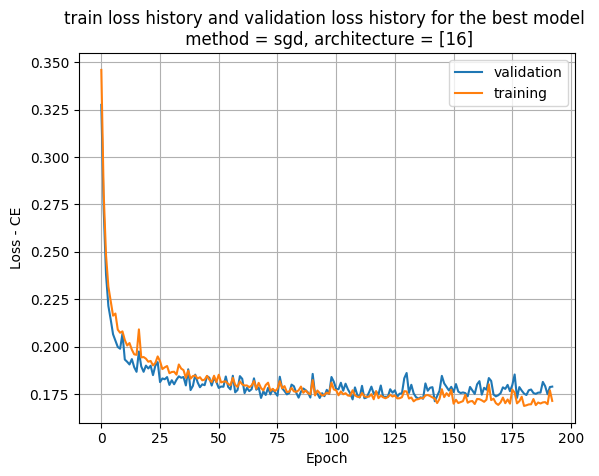

In [21]:
# TODO: Plot training and validation loss curves for the selected/best classifier.

bm_c = classification_results.sort_values("validation_loss").values[0]

plt.plot(range(best_stopped_epoch_c), best_val_loss_history_c, label="validation")
plt.plot(range(best_stopped_epoch_c), best_train_loss_history_c, label="training")

plt.grid()
plt.xlabel("Epoch")
plt.ylabel("Loss - CE")
plt.title(f"train loss history and validation loss history for the best model \n method = {bm_c[0]}, architecture = {bm_c[1]}")
plt.legend()
plt.show()

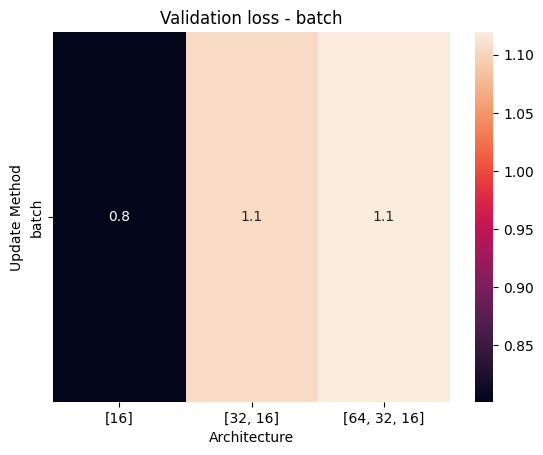

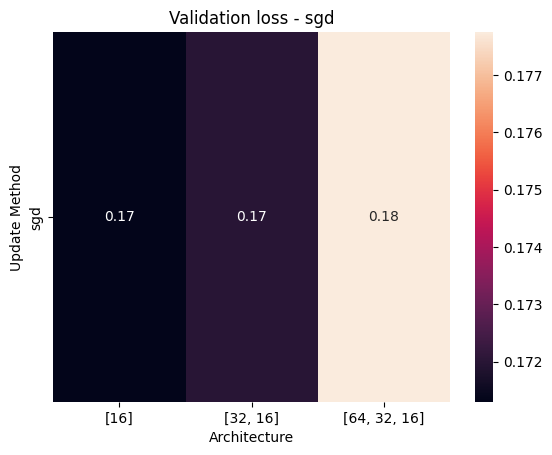

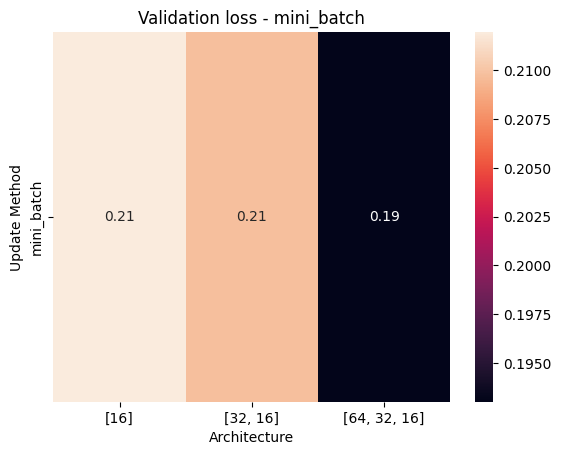

In [22]:
# TODO: Produce one validation-loss heatmap per update method.
# Use architecture labels on the columns.

cr = classification_results.copy()
cr["architecture"] = cr["architecture"].astype(str)

for x in classification_update_methods:
    heatmap_data = cr[cr["update_method"] == x].pivot(
        index="update_method",
        columns="architecture",
        values="validation_loss"
    )

    sns.heatmap(
        heatmap_data,
        annot=True
    )

    plt.title(f"Validation loss - {x}")
    plt.ylabel("Update Method")
    plt.xlabel("Architecture")
    plt.show()


In [23]:
# TODO: Select the final NumPy classifier using validation loss only.
# Then evaluate it on the test set with AUROC, precision, F1, and accuracy.

# Expected variable name for the TensorFlow baseline cell:
# best_classification_layers = ...

whole_X_train_c = np.r_[X_train, X_val]
whole_y_train_c = np.r_[y_train, y_val]

best_update_method_c = bm_c[0]
best_classification_layers = bm_c[1]
goat_epoch_c = bm_c[3]

bestNNC = NeuralNetworkMulticlassClassifier(
    input_size=whole_X_train_c.shape[1],
    hidden_layers=best_classification_layers,
    output_size=whole_y_train_c.shape[1]
)

bestNNC.fit(
    whole_X_train_c,
    whole_y_train_c,
    epochs=goat_epoch_c,
    learning_rate=0.01,
    update_method=best_update_method_c
)

y_test_prob = bestNNC.predict_proba(X_test)
y_test_labels = bestNNC.predict(X_test)

nn_auroc, nn_precision, nn_recall, nn_f1, nn_acurracy = multiclass_metrics(
    y_test,
    y_test_prob,
    y_test_labels
)

nn_classification_results = pd.DataFrame([
    {
        "model": "Numpy Neural Network",
        "architecture": str(list(best_classification_layers)),
        "test_macro_ovr_auroc": nn_auroc,
        "test_accuracy": nn_acurracy,
        "test_macro_precision": nn_precision,
        "test_macro_recall": nn_recall,
        "test_macro_f1": nn_f1,
        "epochs_trained": goat_epoch_c
    }
])

display(nn_classification_results)


,model,architecture,test_macro_ovr_auroc,test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1,epochs_trained
0,Numpy Neural Network,[16],0.994962,0.929481,0.941402,0.936672,0.938778,143


## Scratch Logistic Regression Baseline

Use your own logistic regression implementation from previous labs or courseworks. For this multiclass dataset, you may implement one-vs-rest logistic regression or softmax regression.


In [ ]:
class ScratchLogisticRegression:

    @staticmethod
    def softmax(a: np.ndarray):
        a_shift = a - np.max(a, axis=1, keepdims=True)

        exps = np.exp(a_shift)

        return  exps / np.sum(exps, axis=1, keepdims=True)

    @staticmethod
    def categorical_crossentropy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
        y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
        return -np.sum(y_true * np.log(y_pred)) / y_true.shape[0]

    def fit(self, X, y, epochs=1000, learning_rate=0.01):
        np.random.seed(0)
        W = np.random.normal(scale=0.01, size=(X.shape[1], y.shape[1]))

        cce_history = np.zeros(epochs)

        for cada_epoca in range(epochs):
            for n in range(y.shape[0]):
                a_n = (X[n:n+1]).dot(W)
                y_n = self.softmax(a_n)

                gradiente = (X[n:n+1]).T.dot(y_n - y[n:n+1])
                W -= learning_rate * gradiente

            # Grabando o erro
            y_pred = self.softmax(X.dot(W))
            
            err_epoch = self.categorical_crossentropy(y, y_pred)
            cce_history[cada_epoca] = err_epoch

        self.weight = W
        return cce_history

    def predict_proba(self, X):
        return self.softmax(X.dot(self.weight))

    def predict(self, X):
        prob = self.predict_proba(X)
        labels = np.argmax(prob, axis=1)
        return labels

# TODO: train and evaluate your scratch logistic regression baseline.

SLG = ScratchLogisticRegression()
SLG.fit(whole_X_train_c, whole_y_train_c, classification_epochs)

y_test_prob_sc = SLG.predict_proba(X_test)
y_test_labels_sc = SLG.predict(X_test)

sc_auroc, sc_precision, sc_recall, sc_f1, sc_acurracy = multiclass_metrics(
    y_test,
    y_test_prob_sc,
    y_test_labels_sc
)

sc_classification_results = pd.DataFrame([
    {
        "model": "Scrach Logistic Regression",
        "architecture": "",
        "test_macro_ovr_auroc": sc_auroc,
        "test_accuracy": sc_acurracy,
        "test_macro_precision": sc_precision,
        "test_macro_recall": sc_recall,
        "test_macro_f1": sc_f1,
        "epochs_trained": classification_epochs
    }
])

In [27]:
display(sc_classification_results)

,model,architecture,test_macro_ovr_auroc,test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1,epochs_trained
0,Scrach Logistic Regression,,0.994647,0.916259,0.929354,0.929218,0.928966,1000


## TensorFlow Classification Baseline

This baseline is provided. Run it after you have created `X_train`, `X_val`, `X_test`, `y_train`, `y_val`, `y_test`, `class_names`, and `best_classification_layers`.


In [25]:
import tensorflow as tf
from sklearn.metrics import precision_recall_fscore_support

tf.random.set_seed(0)

if "best_classification_layers" not in globals():
    raise NameError("Define best_classification_layers from your validation search before running this cell.")

classification_patience = globals().get("classification_patience", 50)
classification_epochs = globals().get("classification_epochs", 1000)
classification_learning_rate = globals().get("classification_learning_rate", 0.01)

tf_classification_model = tf.keras.Sequential()
tf_classification_model.add(tf.keras.layers.Input(shape=(X_train.shape[1],)))
for units in best_classification_layers:
    tf_classification_model.add(tf.keras.layers.Dense(int(units), activation="sigmoid"))
tf_classification_model.add(tf.keras.layers.Dense(y_train.shape[1], activation="softmax"))

tf_classification_model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=classification_learning_rate),
    loss="categorical_crossentropy",
)

tf_classification_history = tf_classification_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=classification_epochs,
    batch_size=256,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=classification_patience,
            restore_best_weights=True,
        )
    ],
    verbose=0,
)

tf_classification_probabilities = tf_classification_model.predict(X_test, verbose=0)
tf_classification_predictions = np.argmax(tf_classification_probabilities, axis=1)
tf_true_labels = np.argmax(y_test, axis=1)

tf_precision, tf_recall, tf_f1, _ = precision_recall_fscore_support(
    tf_true_labels,
    tf_classification_predictions,
    average="macro",
    zero_division=0,
)

tf_classification_results = pd.DataFrame([
    {
        "model": "TensorFlow classification baseline",
        "architecture": str(list(best_classification_layers)),
        "test_macro_ovr_auroc": roc_auc_score(y_test, tf_classification_probabilities, average="macro"),
        "test_accuracy": accuracy_score(tf_true_labels, tf_classification_predictions),
        "test_macro_precision": tf_precision,
        "test_macro_recall": tf_recall,
        "test_macro_f1": tf_f1,
        "epochs_trained": len(tf_classification_history.history["loss"]),
    }
])

display(tf_classification_results)


,model,architecture,test_macro_ovr_auroc,test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1,epochs_trained
0,TensorFlow classification baseline,[16],0.994494,0.917238,0.930174,0.927588,0.928731,1000


,model,architecture,test_macro_ovr_auroc,test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1,epochs_trained
0,Numpy Neural Network,[16],0.994962,0.929481,0.941402,0.936672,0.938778,143
1,Scrach Logistic Regression,,0.994647,0.916259,0.929354,0.929218,0.928966,1000
2,TensorFlow classification baseline,[16],0.994494,0.917238,0.930174,0.927588,0.928731,1000


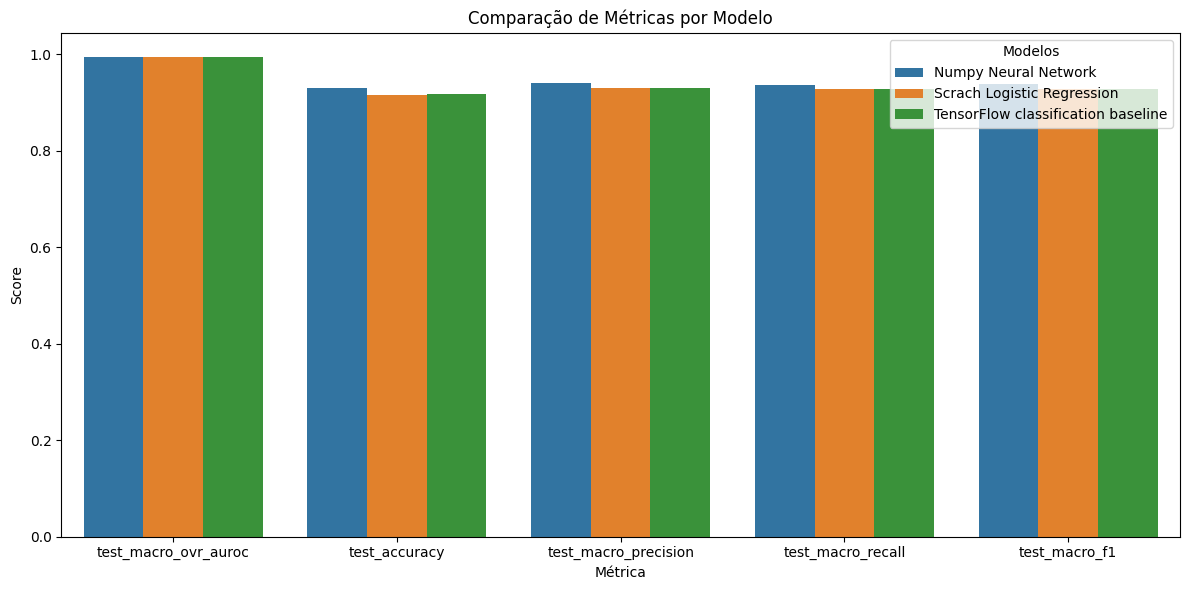

In [26]:
# TODO: Build the final classification comparison table and barplots.
# Include at least:
# - your NumPy NN
# - your scratch logistic regression
# - the TensorFlow baseline above

nn_results = nn_classification_results
sc_results = sc_classification_results
tf_results = tf_classification_results

results = pd.concat([nn_results, sc_results, tf_results], ignore_index=True)

display(results)

cols_metricas = ['test_macro_ovr_auroc', 'test_accuracy', 'test_macro_precision', 
                 'test_macro_recall', 'test_macro_f1']

df_long = results.melt(id_vars='model', 
                  value_vars=cols_metricas, 
                  var_name='metrica', 
                  value_name='valor')

plt.figure(figsize=(12, 6))

sns.barplot(
    data=df_long, 
    x='metrica', 
    y='valor', 
    hue='model'
)

plt.title('Comparação de Métricas por Modelo')
plt.xticks()
plt.ylabel('Score')
plt.xlabel('Métrica')
plt.legend(title='Modelos')
plt.tight_layout()
plt.show()